# 第7章 指令微调（Instruction Fine-tuning）


In [34]:
from importlib.metadata import version

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.2.6
matplotlib version: 3.10.8
tiktoken version: 0.12.0
torch version: 2.7.1+cu118
tqdm version: 4.67.3
tensorflow version: 2.21.0


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/01.webp" width=500px>

- 在第 5 章中，我们看到预训练 LLM 的过程是让模型学习逐个生成单词。因此，预训练的 LLM 擅长文本续写，但不擅长遵循指令
- 在本章中，我们将教会 LLM 更好地遵循指令


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/02.webp" width=500px>

- 下图总结了本章涵盖的主题<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/03.webp" width=500px>

## 7.2 准备用于监督指令微调的数据集


In [35]:
import json
import os
import requests


def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text_data = response.text
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [36]:
# 加载的数据集是一个列表，其中每个元素都是一个包含 "instruction" "input" "output" 键的字典
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [37]:
# 数据中的input可能为空
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


- 指令微调通常被称为"监督指令微调"，因为它需要在明确提供输入输出对的数据集上训练模型
- 将数据格式化为 LLM 的输入有多种方法；下图展示了两种示例格式，分别用于训练 Alpaca（https://crfm.stanford.edu/2023/03/13/alpaca.html）和 Phi-3（https://arxiv.org/abs/2404.14219）LLM

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/04.webp?2" width=500px>


- 在本章中，我们使用 Alpaca 风格的提示格式，这是指令微调的经典提示模板
- 下面，我们将数据格式化为传递给 LLM 的输入


In [38]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [39]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [40]:
# 没有input字段的数据会自动过滤
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [41]:
# 然后把数据划分成数据集，验证集和测试集
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [42]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 将数据组织成训练批次

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/05.webp?1" width=500px>

在之前的章节中，训练批次是通过Pytorch的DataLoader类创建的，该类使用默认的collate_fn函数将数据样本组织成批次。然而，在指令微调中，我们需要一个自定义的collate_fn函数来处理输入和输出文本的格式化和编码。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/06.webp?1" width=500px>

- 首先，我们实现一个 `InstructionDataset` 类，它对数据集中的所有输入进行预分词，类似于第 6 章中的 `SpamDataset`
- 完成了下图中的2.1和2.2步骤
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/07.webp?1" width=500px>


In [43]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            # 获得预分词文本，然后使用tokenizer进行编码
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

- 与第 6 章类似，我们希望批量处理多个训练样本以加速训练，这需要将所有输入填充到相同的长度
- 同样，我们使用 “<|endoftext|>”标记作为填充符


In [44]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 在第 6 章中，我们将所有示例统一填充到数据集中的全局最大长度
- 本章我们采用了一种更高效的方法：开发一个自定义的 `collate_fn`（批处理函数）传递给数据加载器
- 这个函数会将**当前批次**内的样本填充到该批次的最大长度。这意味着同一个 Batch 内长度是统一的，但不同 Batch 之间可以根据实际数据动态变化

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/08.webp?1" width=500px>

In [45]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cuda"
):
    # 找出批次中最长的序列
    # 并将最大长度加 1，以便在下面添加一个额外的
    # 填充标记（为后续创建 Target 做准备）
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充并准备输入数据
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # 添加一个 EOT（序列结束）标记
        new_item += [pad_token_id]
        # 将序列填充至 batch_max_length
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # 通过 padded[:-1]，我们去掉了因 +1 而添加的
        # 那个额外填充标记（稍后会解释其用途）
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # 将输入列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor


In [46]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/09.webp?1" width=400px>

- 上面的代码仅返回了 LLM 的输入数据，但为了训练，我们还需要目标值
- 与预训练类似，这里的做法是将输入序列向右移动一位作为目标值，让模型学会预测下一个标记

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/10.webp?1" width=400px>



In [47]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cuda"
):
    # 找出批次中最长的序列
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充并准备输入与目标数据
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # 添加一个填充标记
        new_item += [pad_token_id]
        # 将序列填充至最大长度
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # 截断最后一个标记作为输入
        targets = torch.tensor(padded[1:])  # 目标向右移动一位
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # 将输入列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


In [48]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]], device='cuda:0')


- 接下来，我们引入 `ignore_index` 参数，将所有的填充标记替换为一个特定值。其目的是在计算损失函数时自动忽略这些填充部分（稍后会详细解释）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/11.webp?1" width=400px>

- 具体来说，就是将填充标记的 Token ID `50256` 替换为 `-100`，如下所示：

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/12.webp?2" width=500px>

- （此外，我们还引入了 `allowed_max_length` 参数来限制样本长度；如果您打算使用的自定义数据集超过了 GPT-2 模型支持的 1024 个 Token 上下文长度，这个参数将非常实用）


In [49]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cuda"
):
    # 找出批次中最长的序列
    batch_max_length = max(len(item)+1 for item in batch)

    # 填充并准备输入与目标数据
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # 添加一个填充标记
        new_item += [pad_token_id]
        # 将序列填充至最大长度
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])  # 截断最后一个标记作为输入
        targets = torch.tensor(padded[1:])  # 目标向右移动一位

        # 新增：将目标中除第一个填充标记外的所有填充标记替换为 ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # 新增：可选地截断至最大序列长度
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # 将输入和目标列表转换为张量并传输到目标设备
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor


In [50]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]], device='cuda:0')


- 让我们来看看将标签替换为 -100 的实际效果。为了便于说明，我们假设一个类似于第 6 章的小型分类任务，它包含 0 和 1 两个类别标签
- 假设我们有以下 logits 值（即模型最后一层的输出），其损失计算如下：


In [51]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [52]:
# 现在 再添加一个训练示例将影响损失
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [53]:
# 把3rd 训练示例的标签替换为 -100
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


- 正如我们所见，这 3 个样本的最终损失与只有 2 个样本时的损失相同。这意味着交叉熵损失函数自动忽略了带有 -100 标签的样本
- 在 PyTorch 中，`cross_entropy` 函数默认设置了 `ignore_index=-100`，用于忽略对应的样本。利用这一特性，我们可以忽略 Batch 中为了对齐长度而添加的多余填充标记
- 需要注意的是，我们**不想忽略**第一个结束标记（ID 为 50256），因为它能向 LLM 发出“回答已结束”的信号


## 7.4 为指令数据集创建数据加载器
- 在本节中，我们将使用 `InstructionDataset` 类和 `custom_collate_fn` 函数来创建训练集、验证集和测试集的数据加载器
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/14.webp" width=500px>

- 关于 `custom_collate_fn` 函数的另一个细节是：我们现在直接将数据移动到目标设备（如 GPU），而不是在主训练循环中执行。这样做提高了效率，因为当 `custom_collate_fn` 作为 DataLoader 的一部分时，它可以作为后台进程并行执行
- 借助 Python `functools` 标准库中的 `partial` 函数，我们可以创建一个新函数，预先填充好原始函数的 `device` 参数


In [54]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [55]:
from functools import partial
# 简单说：partial = 参数预设器。
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

- 接下来，我们实例化与前面的章节类似的数据加载器，不同之处在于我们现在为批处理过程提供自己的collate函数

In [56]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [57]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [58]:
print("Train loader:")
for inputs, targets in train_loader:
    # pass

    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

- 从上面的输出可以看出，每个 Batch 的大小都是 8，但序列长度各不相同，符合预期
- 我们还可以通过打印第一个 Batch 中输入样本的内容，来检查其中是否包含与 Token ID 50256对应的“<|endoftext|>”填充标记


In [59]:
print(inputs[0])

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')


In [60]:
# 也可以查看target中有没有 -100 的标签
print(targets[0])

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   198,   198, 21017,
        46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,   985,
          576,    13,   198,   198, 21017, 23412,    25,   198,   464,  5156,
          318,   845, 13779,    13,   198,   198, 21017, 18261,    25,   198,
          464,  5156,   318,   355, 13779,   355,   257,  4936,    13, 50256,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')


## 7.5 加载预训练的 LLM
- 在本节中，我们使用第 5 章 5.5 节和第 6 章 6.4 节中使用的相同代码加载预训练的 GPT 模型
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/15.webp?1" width=500px>
- 然而，我们本章没有加载最小的 1.24 亿参数模型，而是选择了 3.55 亿参数的中等版本。因为小模型的能力有限，微调后很难产生合理的指令遵循效果


In [61]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 76.8kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [01:55<00:00, 9.00kiB/s]
hparams.json: 100%|██████████| 91.0/91.0 [00:00<00:00, 18.2kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 1.42G/1.42G [04:14<00:00, 5.58MiB/s]  
model.ckpt.index: 100%|██████████| 10.4k/10.4k [00:00<00:00, 10.5MiB/s]
model.ckpt.meta: 100%|██████████| 927k/927k [00:01<00:00, 600kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 431kiB/s]  


- 在我们开始在下一节中微调模型之前，让我们看看它在其中一个验证任务上的执行情况

In [62]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [63]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [67]:
response_text = (
    generated_text[len(input_text):]
)
print(response_text)



### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## 7.6 指令微调 LLM

- 在本节中，我们对模型进行微调<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/16.webp" width=500px>
- 请注意，我们可以重用前面章节中使用的损失计算函数和训练函数

In [69]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)



- 让我们在开始训练之前计算初始训练和验证集损失（如前面的章节所示，目标是最小化损失）

In [70]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259105682373047
Validation loss: 3.7619349002838134


In [71]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

- 从上面的输出可以看出，随着训练损失和验证损失的不断下降，模型训练效果良好
- 此外，从每个 epoch 后打印的文本可以看出，模型已学会遵循指令，例如正确地将主动语态句子 "The Chef Cooks the Mee every day." 转换为被动语态 "The Mee is Cooked every day by the Chef."
- 最后，让我们来看看训练和验证的损失曲线


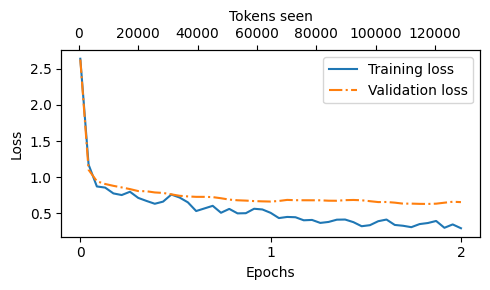

In [72]:
# 训练完成后，我们可以绘制训练和验证损失随时间的变化情况，以评估模型的学习效果
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 7.7 提取和保存响应
<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/18.webp?1" width=500px>
- 在本节中，我们将保存测试集的生成结果，以便在下一节进行评分；同时也会保存一份模型副本供以后使用
- 首先，让我们简单浏览一下微调模型生成的回答



In [73]:
torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
)

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pre

- 从测试集的指令、标准答案和模型生成结果来看，模型的整体表现相当不错。首尾两个问题的答案显然是正确的；第二个答案也非常接近，模型输出了“积云”而非“积雨云”（注：积云本身确实可发展为积雨云并引发雷暴，因此该回答具备一定合理性）
- 更重要的是，指令微调模型的评估远比上一章的分类任务复杂。在垃圾邮件分类中，只需计算预测正确的比例即可得到准确率。但在实际应用中，评估指令遵循模型（如聊天机器人）通常需要综合多种方法：
  - **标准化知识基准**：如 MMLU（大规模多任务语言理解），通过简答和选择题测试模型的知识储备
  - **人类偏好对比**：如 LMSYS 聊天机器人竞技场，比较不同模型回答的实际偏好度
  - **自动化模型评估**：利用更强的 LLM（如 GPT-4）对生成结果打分，例如 AlpacaEval
- 在下一节中，我们将采用类似 AlpacaEval 的思路，借助另一个大模型来评估我们微调模型的输出。不同的是，我们将使用自建的测试集，而非公开基准数据集
- 为此，我们会将模型生成的回答添加回 `test_data` 字典中，并保存为 `instruction-data-with-response.json` 文件。这样既能完整保留记录，也方便后续在独立的 Python 环境中随时加载与分析


In [74]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

100%|██████████| 110/110 [05:47<00:00,  3.16s/it]


In [75]:
# 检查其中的一个条目，看看是否正确添加了模型响应
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a cheetah.'}


In [76]:
# 最后保存模型来备用
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

Model saved as gpt2-medium355M-sft.pth


## 7.8 评估微调后的 LLM

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/19.webp?1" width=500px>

- 在本节中，我们将利用另一个更大的 LLM 来自动评估微调模型的生成结果
- 具体来说，我们将使用 Ollama 工具在本地运行（或调用各大厂商LLM的API）


In [ ]:
import psutil
# 检查ollama有没有运行
def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

In [ ]:
# This cell is optional; it allows you to restart the notebook
# and only run section 7.7 without rerunning any of the previous code
import json
from tqdm import tqdm

file_path = "instruction-data-with-response.json"

with open(file_path, "r") as file:
    test_data = json.load(file)


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [82]:
import requests
import os

def query_model(
    prompt,
    model="GLM-4-Flash-250414",  # 智谱模型（可选 glm-4 / glm-4-air 等）
    url="https://open.bigmodel.cn/api/paas/v4/chat/completions"
):
    # 1. 获取 API Key（强烈建议通过环境变量传入）
    api_key = os.getenv("ZHIPU_API_KEY", "sk-你的智谱API_Key_请替换")

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    # 2. 构造请求体（兼容 OpenAI 格式）
    data = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.0  # 评估时必须固定为 0，保证打分稳定可复现
    }

    # 3. 发送请求
    response = requests.post(url, headers=headers, json=data, timeout=45)
    response.raise_for_status()

    # 4. 解析返回结果
    result = response.json()
    return result["choices"][0]["message"]["content"]

# 连通性测试
print(query_model("羊驼通常吃什么？"))


羊驼（Alpaca）是食草动物，它们主要吃以下几种东西：

1.  **草 (Grass):** 这是羊驼最主要的食物来源。它们在野外会大量吃草，尤其是在牧场上。它们喜欢各种牧草，如禾本科草（如牧草、黑麦草）和豆科草（如苜蓿草）。

2.  **干草 (Hay):** 当户外没有足够的草或者天气不适合放牧时（比如冬天或雨季），会提供干草作为补充。常见的干草有禾本科干草（如燕麦草、黑麦草干草）和豆科干草（如苜蓿干草）。干草提供了必需的营养和纤维。

3.  **补充饲料/颗粒饲料 (Concentrates/Feed Pellets):** 这不是羊驼的主要食物，而是作为补充。补充饲料通常富含能量、蛋白质、维生素和矿物质，用于满足羊驼特定的生长、生产（如产毛、产肉）或健康需求。通常按需添加，而不是无限供应，以防止肥胖。

4.  **水 (Water):** 清洁充足的饮水对羊驼至关重要，它们需要不断饮水来维持生命活动。

**总结来说，羊驼的天然饮食以各种牧草为主，辅以干草。补充饲料只是根据需要提供的营养补充。** 它们不会吃肉、谷物（通常少量作为补充，过量有害）或人类食物。


In [83]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> I would score the model response `The car is as fast as a cheetah.` an 85 out of 100.

The response successfully uses a simile to rewrite the original sentence, which is the primary requirement. The comparison to a cheetah is appropriate and effectively conveys the idea of great speed, making it a strong and fitting simile. However, it might not be as universally recognized or impactful as comparing the car's speed to lightning, which is a common and vivid metaphor for extreme speed.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.

Score:
>> 50

-------------------------

Dataset response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.

Score:
>> score: 100

---------

In [87]:
def generate_model_scores(json_data, json_key, model="GLM-4-Flash-250414"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [01:16<00:00,  1.43it/s]

Number of scores: 110 of 110
Average score: 46.77



## 7.9 模型总结
- 在本章中，我们介绍了指令微调的概念，并展示了如何准备数据、创建数据加载器、加载预训练模型、进行微调以及评估微调后的模型
- 通过指令微调，我们可以显著提升 LLM 在遵循指令方面的能力，使其在实际应用中表现更好
- 评估指令微调模型的性能是一个复杂的任务，通常需要结合多种方法，包括标准化基准、人工评估和自动化模型评估等
- 在下一章中，我们将继续探索更高级的微调方法，如强化学习微调（RLHF）和基于人类反馈的微调（RLHF），以进一步提升模型的性能和实用性